In [1]:
from torchvision.io.image import decode_image
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights, fcn_resnet101, FCN_ResNet101_Weights, LRASPP_MobileNet_V3_Large_Weights, lraspp_mobilenet_v3_large
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt

In [28]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# weights = FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1;
# model = fcn_resnet50(weights=weights).to(DEVICE)

# weights = FCN_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1;
# model = fcn_resnet101(weights=weights).to(DEVICE)

weights = LRASPP_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1;
model = lraspp_mobilenet_v3_large(weights=weights).to(DEVICE)

_ = model.eval()

In [29]:
img = decode_image("../imagenes/object_detection/car3.jpg")
if img.shape[0] == 4:
    img = img[:3, :, :]

In [30]:
transform = transforms.Compose([
    # transforms.Resize((1024, 1024)),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img_tensor = transform(img)

img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

In [31]:
class_to_idx = {cls: idx for (idx, cls) in enumerate(weights.meta["categories"])}
category = class_to_idx["__background__"]

In [32]:
with torch.no_grad():
    prediction = model(img_tensor)["out"]
    prediction_image = prediction.softmax(dim=1)
    # prediction_image = prediction.sigmoid()
    
    predicted_mask = prediction_image[0, category].cpu()

In [33]:
binary_mask = (predicted_mask < 0.95).float()

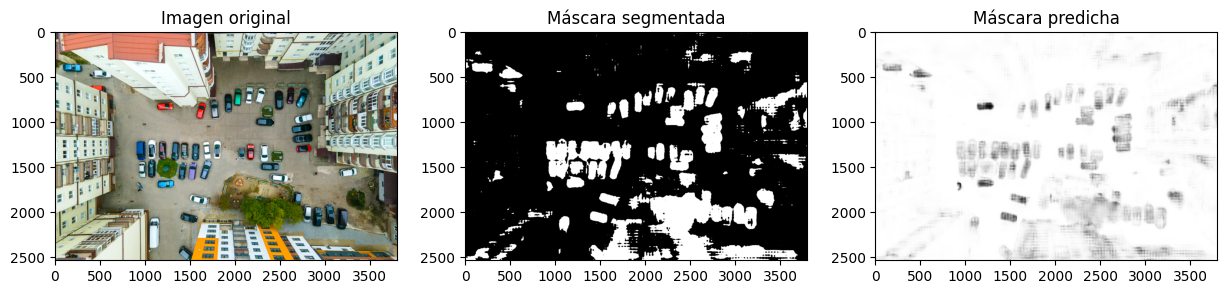

In [34]:
plt.figure(figsize=(20,4))
plt.subplot(1,3,1)
plt.title("Imagen original")
plt.imshow(img.permute(1, 2, 0).cpu().numpy())
plt.subplot(1,3,2)
plt.title(f"Máscara segmentada")
plt.imshow(binary_mask, cmap='gray')
plt.subplot(1,3,3)
plt.title(f"Máscara predicha")
plt.imshow(predicted_mask.detach().cpu().numpy(), cmap='gray')
plt.show()

In [27]:
torch.cuda.empty_cache()

In [36]:
import inspect
print(inspect.signature(decode_image))

(input: Union[torch.Tensor, str], mode: torchvision.io.image.ImageReadMode = <ImageReadMode.UNCHANGED: 0>, apply_exif_orientation: bool = False) -> torch.Tensor
